In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

log_reg = LogisticRegression(max_iter=3000, n_jobs=-1, random_state=42)

param_dist = {
    "solver": ["liblinear", "saga"],
    "penalty": ["l1", "l2"],          # (elasticnet hanya untuk solver='saga' + l1_ratio)
    "C": loguniform(1e-3, 1e2),
    "class_weight": [None, "balanced", {0:1, 1:2}, {0:1, 1:3}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
rs = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,
    scoring={"recall": "recall", "roc_auc": "roc_auc", "precision":"precision","f1":"f1"},
    refit="recall",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X_train, y_train.ravel())


Fitting 5 folds for each of 50 candidates, totalling 250 fits


d:\Rakamin_SupervisedLearning2\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(max_iter=3000, n_jobs=-1,
                                                random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000025501A6B970>,
                                        'class_weight': [None, 'balanced',
                                                         {0: 1, 1: 2},
                                                         {0: 1, 1: 3}],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=42, refit='recall',
                   scoring={'f1': 'f1', 'precision': 'precision',
                            'recall': 'recall', 'roc_auc': 'roc_auc'},
                   verbose=1)

In [11]:
print(rs.best_params_)     # kombinasi hyperparameter terbaik
print(rs.best_score_)      # skor CV untuk metrik refit (recall, di kasusmu)


{'C': np.float64(40.679084943595456), 'class_weight': {0: 1, 1: 3}, 'penalty': 'l2', 'solver': 'liblinear'}
0.8066889632107023


In [12]:
best_model = rs.best_estimator_  # LogisticRegression dengan hyperparameter terbaik
y_pred = best_model.predict(X_test)

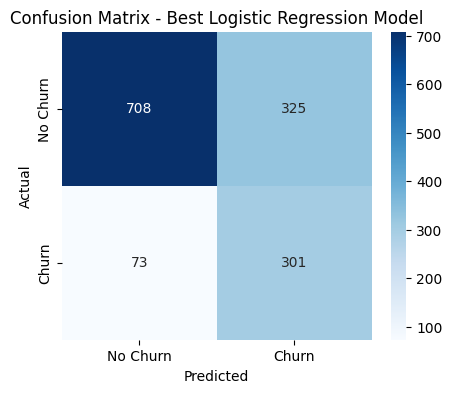

In [16]:
cm_best = confusion_matrix(y_test, y_pred)
# Plot confusion matrix for the best model
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Logistic Regression Model")
plt.show()